In [1]:
# Import library utama
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Modeling
from sklearn.ensemble import RandomForestClassifier

# Evaluasi
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# IMPORT DATA

In [2]:
base_url = "https://raw.githubusercontent.com/Shafaftm/Project-Pengantar-Data-Sains/main/Data/"

data_train = pd.read_excel(base_url + "data_titanic.xlsx")
data_test  = pd.read_excel(base_url + "data_prediksi.xlsx")
data_train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
data_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# Pre Processing dan EDA

### Struktur Data

In [4]:
#Cek Struktur Data
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


### Periksa Data Duplikat

In [6]:
#CEK DATA DUPLIKAT
data_test.duplicated().sum()

np.int64(0)

In [7]:
data_train.duplicated().sum()

np.int64(0)

### Mengatasi Missing Value

In [8]:
data_test.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [9]:
#Cek Data Hilang
data_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
#Atasi Missing Value
data_train['Age'].fillna(data_train['Age'].median(), inplace=True)
data_test['Age'].fillna(data_test['Age'].median(), inplace=True)

data_train['Embarked'].fillna(data_train['Embarked'].mode()[0], inplace=True)
data_test['Fare'].fillna(data_test['Fare'].median(), inplace=True)

/tmp/ipython-input-1300064891.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_train['Age'].fillna(data_train['Age'].median(), inplace=True)
/tmp/ipython-input-1300064891.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

### Distribusi Data

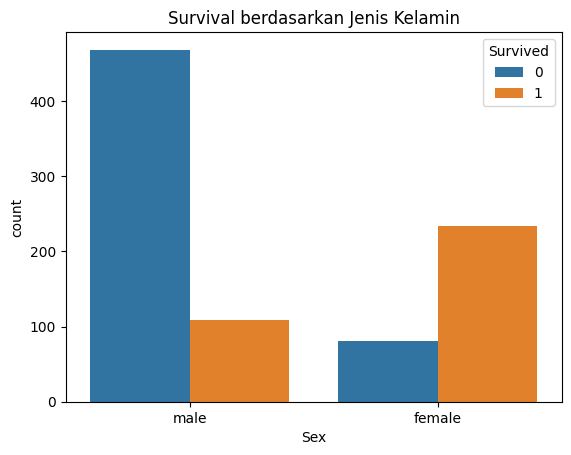

In [11]:
#Cek Distribusi Data
sns.countplot(x='Sex', hue='Survived', data=data_train)
plt.title("Survival berdasarkan Jenis Kelamin")
plt.show()


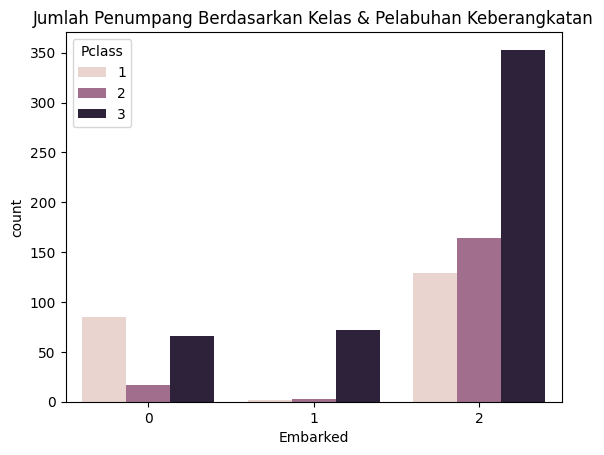

In [69]:
#Cek Distribusi Data
sns.countplot(x='Embarked', hue='Pclass', data=data_train)
plt.title("Jumlah Penumpang Berdasarkan Kelas & Pelabuhan Keberangkatan")
plt.show()

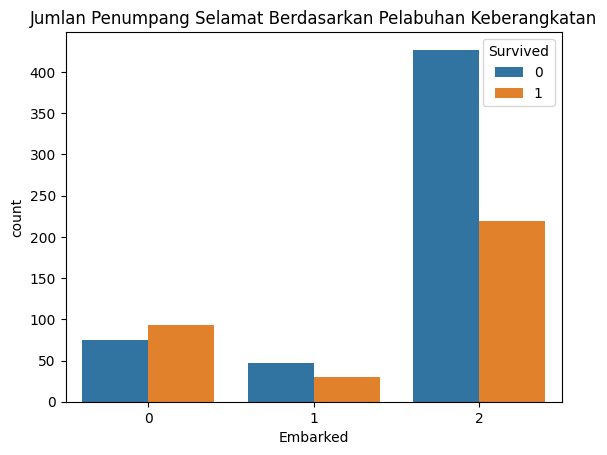

In [70]:
sns.countplot(x='Embarked', hue='Survived', data=data_train)
plt.title("Jumlan Penumpang Selamat Berdasarkan Pelabuhan Keberangkatan")
plt.show()

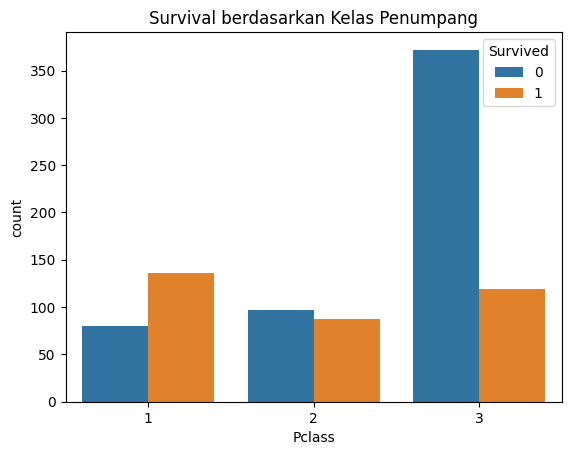

In [12]:
sns.countplot(x='Pclass', hue='Survived', data=data_train)
plt.title("Survival berdasarkan Kelas Penumpang")
plt.show()

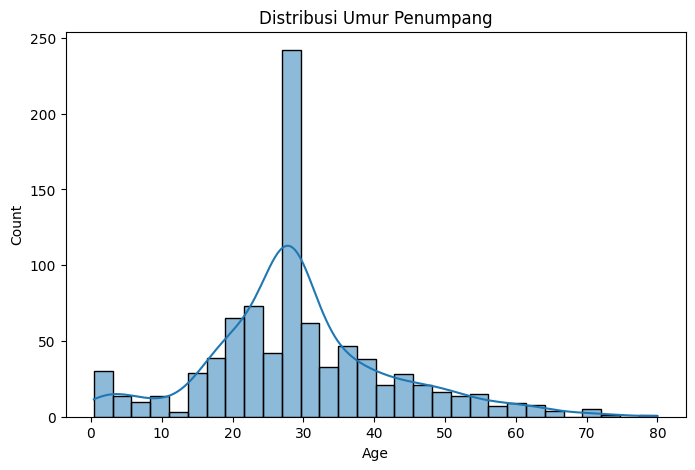

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(data_train['Age'], bins=30, kde=True)
plt.title("Distribusi Umur Penumpang")
plt.show()


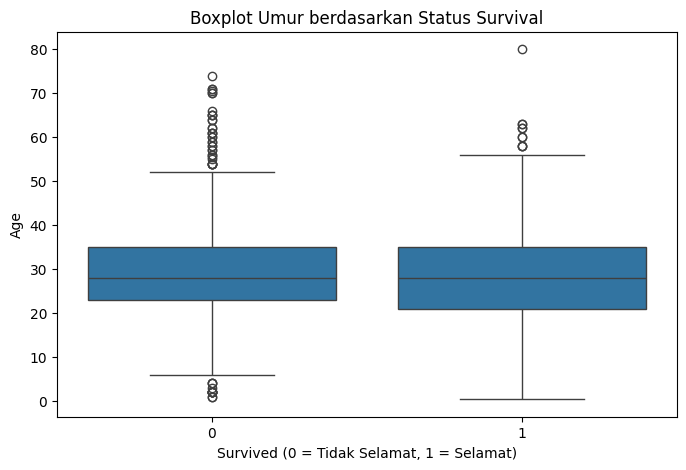

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Age', data=data_train)
plt.title("Boxplot Umur berdasarkan Status Survival")
plt.xlabel("Survived (0 = Tidak Selamat, 1 = Selamat)")
plt.ylabel("Age")
plt.show()


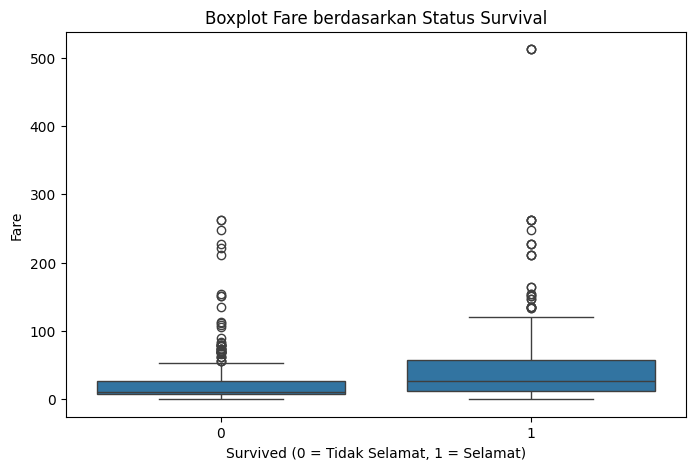

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Fare', data=data_train)
plt.title("Boxplot Fare berdasarkan Status Survival")
plt.xlabel("Survived (0 = Tidak Selamat, 1 = Selamat)")
plt.ylabel("Fare")
plt.show()


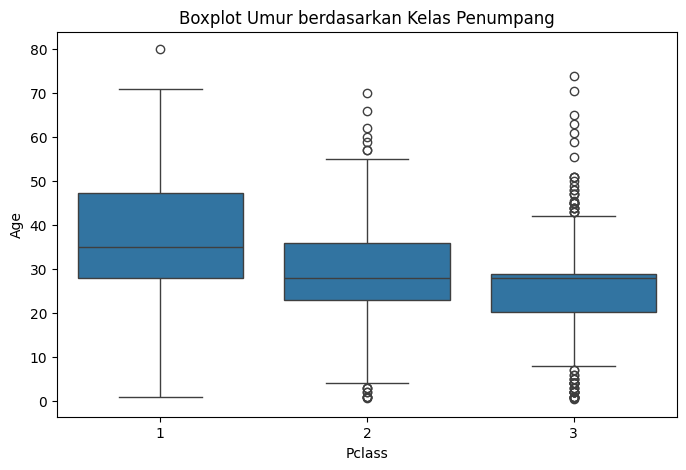

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Pclass', y='Age', data=data_train)
plt.title("Boxplot Umur berdasarkan Kelas Penumpang")
plt.xlabel("Pclass")
plt.ylabel("Age")
plt.show()


### Korelasi Data

In [57]:
data_corr = data_train[['Survived','Age','Sex','Fare','Pclass','SibSp','Parch','Embarked']]
data_corr.corr()


,Survived,Age,Sex,Fare,Pclass,SibSp,Parch,Embarked
Survived,1.000000,-0.064910,-0.543351,0.257307,-0.338481,-0.035322,0.081629,-0.167675
Age,-0.064910,1.000000,0.081163,0.096688,-0.339898,-0.233296,-0.172482,-0.018754
Sex,-0.543351,0.081163,1.000000,-0.182333,0.131900,-0.114631,-0.245489,0.108262
Fare,0.257307,0.096688,-0.182333,1.000000,-0.549500,0.159651,0.216225,-0.224719
Pclass,-0.338481,-0.339898,0.131900,-0.549500,1.000000,0.083081,0.018443,0.162098
SibSp,-0.035322,-0.233296,-0.114631,0.159651,0.083081,1.000000,0.414838,0.068230
Parch,0.081629,-0.172482,-0.245489,0.216225,0.018443,0.414838,1.000000,0.039798
Embarked,-0.167675,-0.018754,0.108262,-0.224719,0.162098,0.068230,0.039798,1.000000


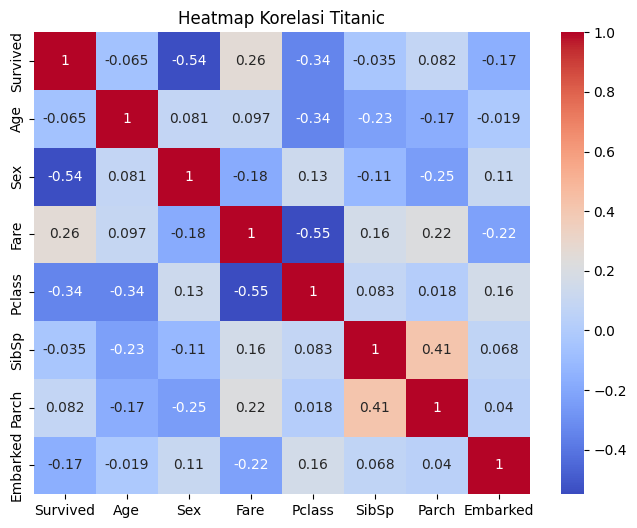

In [58]:
plt.figure(figsize=(8,6))
sns.heatmap(data_corr.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Titanic')
plt.show()

### Periksa Outlier

In [18]:
data_numerik = ['Age', 'SibSp', 'Parch', 'Fare']
def cek_outlier_iqr(data_train, kolom_numerik):
    hasil = {}
    for kolom in kolom_numerik:
        Q1 = data_train[kolom].quantile(0.25)
        Q3 = data_train[kolom].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier = data_train[(data_train[kolom] < lower_bound) |
                              (data_train[kolom] > upper_bound)]

        hasil[kolom] = {
            "Jumlah Outlier": outlier.shape[0],
        }
    return pd.DataFrame(hasil).T
    data_numerik = ['Age', 'SibSp', 'Parch', 'Fare']

outlier_summary = cek_outlier_iqr(data_train, data_numerik)
outlier_summary


,Jumlah Outlier
Age,66
SibSp,46
Parch,213
Fare,116


### Feature Engineering

In [19]:
#FEATURE ENGINEERING
data_train['FamilySize'] = data_train['SibSp'] + data_train['Parch'] + 1
data_test['FamilySize']  = data_test['SibSp'] + data_test['Parch'] + 1

data_train['IsAlone'] = np.where(data_train['FamilySize'] == 1, 1, 0)
data_test['IsAlone']  = np.where(data_test['FamilySize'] == 1, 1, 0)

In [20]:
encoder = LabelEncoder()

for col in ['Sex', 'Embarked']:
   data_train[col] = encoder.fit_transform(data_train[col])
   data_test[col] = encoder.transform(data_test[col])

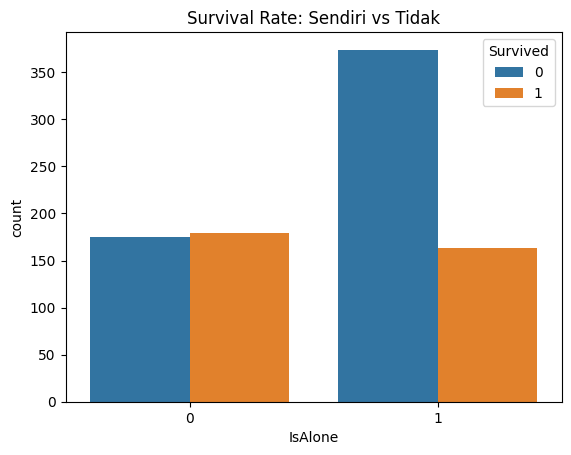

In [52]:
#Cek Distribusi Data
sns.countplot(x='IsAlone', hue='Survived', data=data_train)
plt.title('Survival Rate: Sendiri vs Tidak')
plt.show()


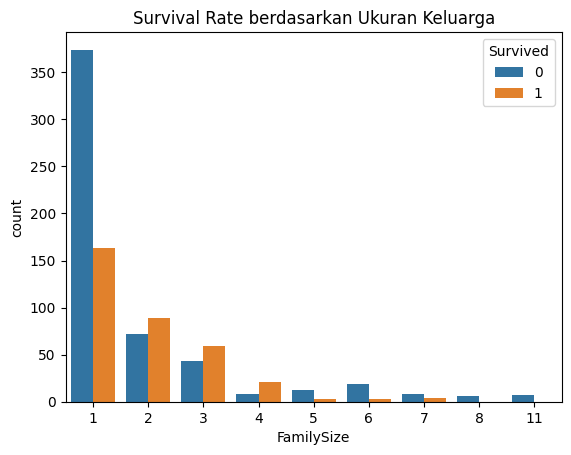

In [55]:
sns.countplot(x='FamilySize', hue='Survived', data=data_train)
plt.title('Survival Rate berdasarkan Ukuran Keluarga')
plt.show()


### Statistik Deskriptif

In [23]:
data = ['Survived', 'Pclass', 'Age', 'FamilySize', 'Fare']
data_train[data].describe()

,Survived,Pclass,Age,FamilySize,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,1.904602,32.204208
std,0.486592,0.836071,13.019697,1.613459,49.693429
min,0.000000,1.000000,0.420000,1.000000,0.000000
25%,0.000000,2.000000,22.000000,1.000000,7.910400
50%,0.000000,3.000000,28.000000,1.000000,14.454200
75%,1.000000,3.000000,35.000000,2.000000,31.000000
max,1.000000,3.000000,80.000000,11.000000,512.329200


In [24]:
target = 'Survived'
feature = ['Sex', 'Age', 'Pclass', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Fare', 'Embarked']

train_model = data_train[feature + [target]].copy()
test_model  = data_test[feature].copy()

train_model.head()

,Sex,Age,Pclass,SibSp,Parch,FamilySize,IsAlone,Fare,Embarked,Survived
0,1,22.0,3,1,0,2,0,7.2500,2,0
1,0,38.0,1,1,0,2,0,71.2833,0,1
2,0,26.0,3,0,0,1,1,7.9250,2,1
3,0,35.0,1,1,0,2,0,53.1000,2,1
4,1,35.0,3,0,0,1,1,8.0500,2,0


In [25]:
train_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Sex         891 non-null    int64  
 1   Age         891 non-null    float64
 2   Pclass      891 non-null    int64  
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   FamilySize  891 non-null    int64  
 6   IsAlone     891 non-null    int64  
 7   Fare        891 non-null    float64
 8   Embarked    891 non-null    int64  
 9   Survived    891 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 69.7 KB


In [26]:
test_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Sex         418 non-null    int64  
 1   Age         418 non-null    float64
 2   Pclass      418 non-null    int64  
 3   SibSp       418 non-null    int64  
 4   Parch       418 non-null    int64  
 5   FamilySize  418 non-null    int64  
 6   IsAlone     418 non-null    int64  
 7   Fare        418 non-null    float64
 8   Embarked    418 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 29.5 KB


### Menentukan Variabel X dan Y

In [27]:
#Menentukan X dan Y
X = train_model.drop('Survived', axis=1)
y = train_model['Survived']

### Split Data

In [28]:
#SPLIT DATA
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# PEMODELAN DATA TITANIC MENGGUNAKAN RANDOM FOREST

In [29]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 8, 12, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,           # jumlah kombinasi acak
    cv=5,                # 5-fold cross validation
    scoring='accuracy',  # bisa ganti f1, recall, roc_auc
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)
print("Parameter terbaik:")
print(random_search.best_params_)

print("Skor CV terbaik:")
print(random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Parameter terbaik:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5, 'bootstrap': False}
Skor CV terbaik:
0.8314094356347876


# EVALUASI MODEL

### Akurasi Model

In [30]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_valid)

print("Akurasi validasi:", accuracy_score(y_valid, y_pred))


Akurasi validasi: 0.8044692737430168


### Confusion Matrix

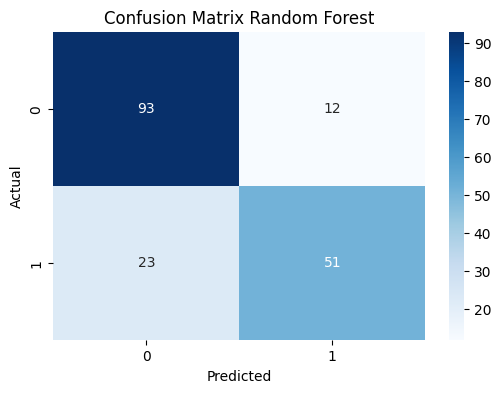

In [31]:
cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Random Forest")
plt.show()


### Classification Report

In [32]:
print(classification_report(y_valid, y_pred))


              precision    recall  f1-score   support

           0       0.80      0.89      0.84       105
           1       0.81      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



# PREDIKSI DATASET

In [33]:
test_prediction = best_rf.predict(test_model)

In [34]:
fitur_model = [
    'Sex', 'Age', 'Fare', 'Pclass',
    'FamilySize', 'IsAlone', 'Embarked',
    'SibSp', 'Parch'
]
hasil_prediksi = test_model[fitur_model].copy()
hasil_prediksi['Survived'] = test_prediction


In [35]:
hasil_prediksi.head()

,Sex,Age,Fare,Pclass,FamilySize,IsAlone,Embarked,SibSp,Parch,Survived
0,1,34.5,7.8292,3,1,1,1,0,0,0
1,0,47.0,7.0000,3,2,0,2,1,0,0
2,1,62.0,9.6875,2,1,1,1,0,0,0
3,1,27.0,8.6625,3,1,1,2,0,0,0
4,0,22.0,12.2875,3,3,0,2,1,1,1


In [36]:
hasil_prediksi['Survived'].value_counts()


,count
Survived,
0,283
1,135


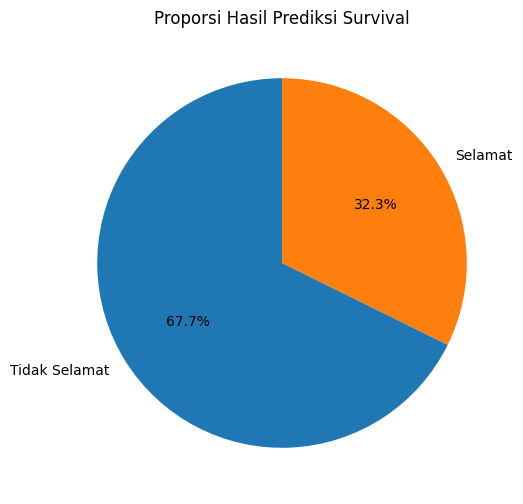

In [37]:
survival_counts = hasil_prediksi['Survived'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    survival_counts,
    labels=['Tidak Selamat', 'Selamat'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Proporsi Hasil Prediksi Survival")
plt.show()


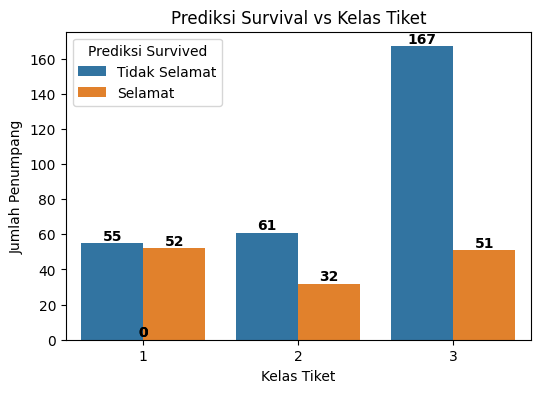

In [47]:
test_model_plot = test_model.copy()
test_model_plot['Survived_Pred'] = test_prediction

plt.figure(figsize=(6,4))
ax = sns.countplot(
    x='Pclass',
    hue='Survived_Pred',
    data=test_model_plot,
    palette=['#1f77b4', '#ff7f0e']  # biru & oranye
)
plt.xlabel('Kelas Tiket')
plt.ylabel('Jumlah Penumpang')
plt.title('Prediksi Survival vs Kelas Tiket')
plt.legend(title='Prediksi Survived', labels=['Tidak Selamat', 'Selamat'])

# Tambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.show()

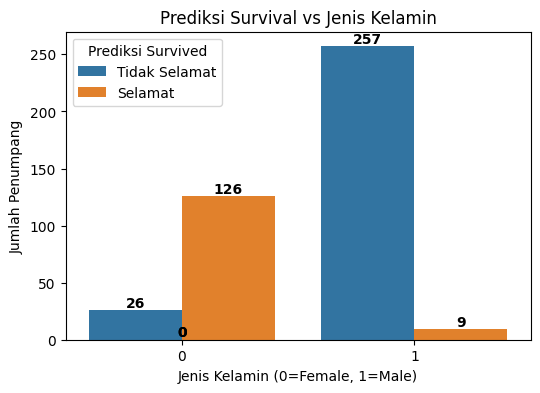

In [50]:
plt.figure(figsize=(6,4))
ax = sns.countplot(
    x='Sex',
    hue='Survived_Pred',
    data=test_model_plot,
    palette=['#1f77b4', '#ff7f0e']
)
plt.xlabel('Jenis Kelamin (0=Female, 1=Male)')
plt.ylabel('Jumlah Penumpang')
plt.title('Prediksi Survival vs Jenis Kelamin')
plt.legend(title='Prediksi Survived', labels=['Tidak Selamat', 'Selamat'])

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.show()

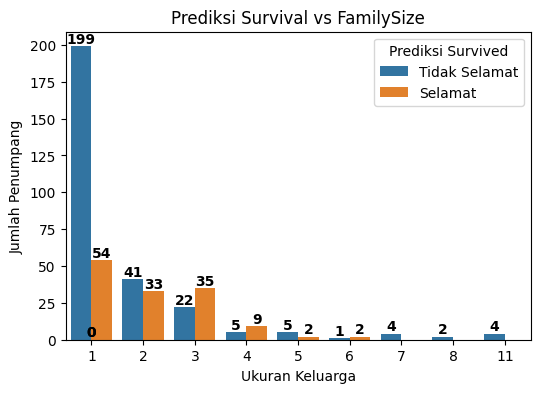

In [40]:
plt.figure(figsize=(6,4))
ax = sns.countplot(
    x='FamilySize',
    hue='Survived_Pred',
    data=test_model_plot,
    palette=['#1f77b4', '#ff7f0e']
)
plt.xlabel('Ukuran Keluarga')
plt.ylabel('Jumlah Penumpang')
plt.title('Prediksi Survival vs FamilySize')
plt.legend(title='Prediksi Survived', labels=['Tidak Selamat', 'Selamat'])

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.show()

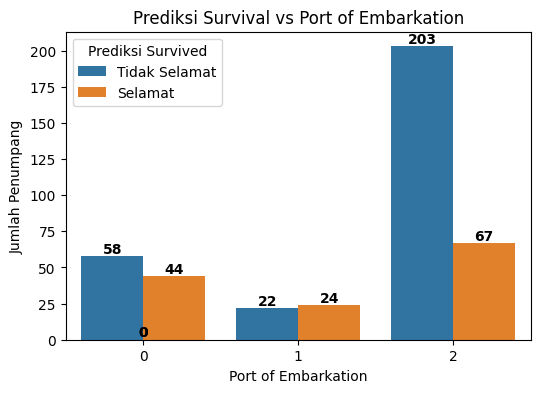

In [49]:
plt.figure(figsize=(6,4))
ax = sns.countplot(
    x='Embarked',
    hue='Survived_Pred',
    data=test_model_plot,
    palette=['#1f77b4', '#ff7f0e']
)
plt.xlabel('Port of Embarkation')
plt.ylabel('Jumlah Penumpang')
plt.title('Prediksi Survival vs Port of Embarkation')
plt.legend(title='Prediksi Survived', labels=['Tidak Selamat', 'Selamat'])

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.show()

### Feature Importance

In [41]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance


,0
Sex,0.513062
Pclass,0.154923
Fare,0.121287
Age,0.089035
FamilySize,0.053837
SibSp,0.022467
Embarked,0.021631
IsAlone,0.014468
Parch,0.009290


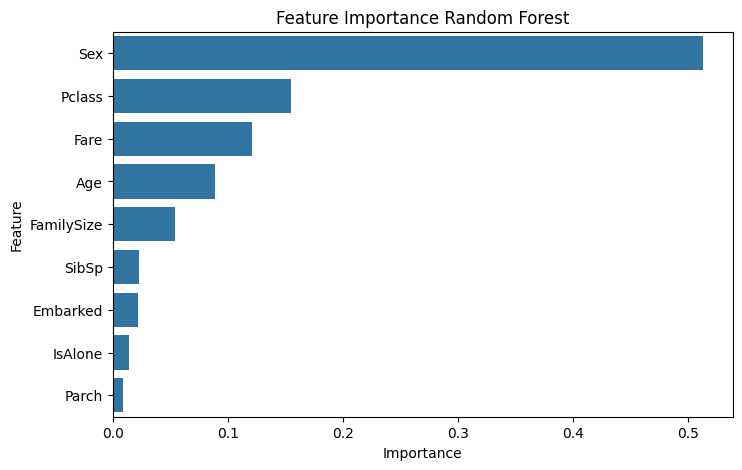

In [42]:
plt.figure(figsize=(8,5))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title("Feature Importance Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [43]:
#Simpan Data hasil Prediksi ke Excel
with pd.ExcelWriter("hasil_prediksi_titanic.xlsx") as writer:
    hasil_prediksi.to_excel(writer, sheet_name='Prediksi', index=False)
    feature_importance.to_excel(writer, sheet_name='Feature_Importance')